<a href="https://colab.research.google.com/github/anselmo-torres/TP2---LAB---Python/blob/main/Ejercicio_6_Optimizaci%C3%B3n_en_dos_dimensiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio 6 - Optimización en dos dimensiones

In [ ]:
# Descargo librerias
import numpy as np
import matplotlib.pyplot as plt

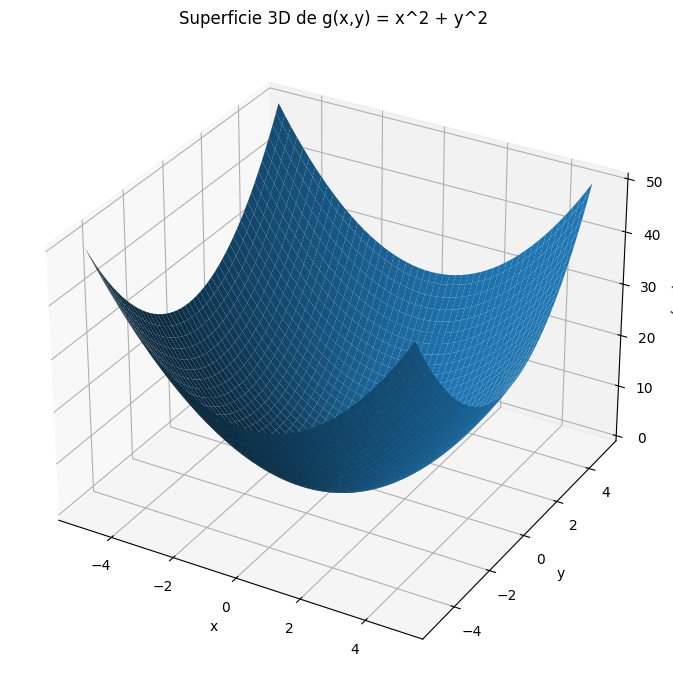

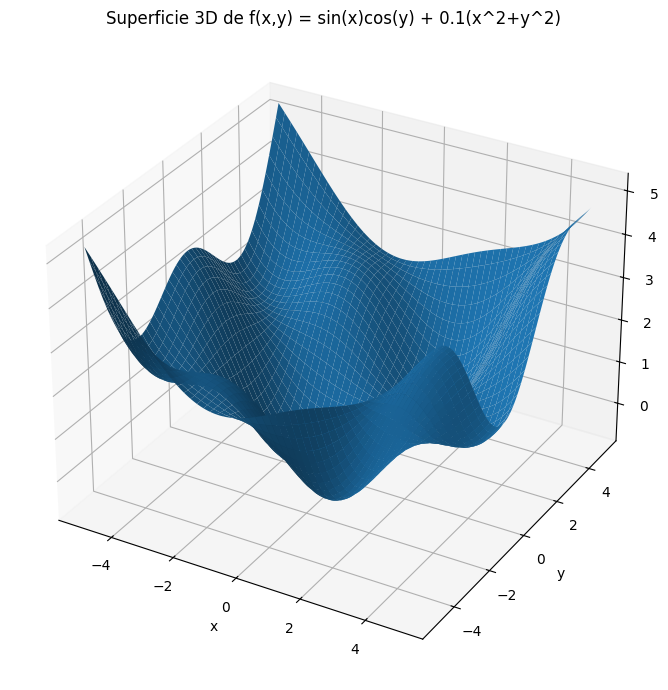

In [ ]:
# Definimos las funciones

def g(x, y):

    return x**2 + y**2

def f(x, y):

    return np.sin(x) * np.cos(y) + 0.1 * (x**2 + y**2)

# Calculamos sus gradientes
def grad_g(x, y):

    dg_dx = 2*x
    dg_dy = 2*y
    return dg_dx, dg_dy

def grad_f(x, y):

    df_dx = np.cos(x) * np.cos(y) + 0.2*x
    df_dy = -np.sin(x) * np.sin(y) + 0.2*y
    return df_dx, df_dy

# construyo matrices X e Y que contienen todas las combinaciones de puntos del plano para poder graficar.

x_min, x_max = -5, 5
y_min, y_max = -5, 5
N = 200  # resolución de la grilla (más alto = más detalle)

x = np.linspace(x_min, x_max, N)
y = np.linspace(y_min, y_max, N)
X, Y = np.meshgrid(x, y)

# Evaluo Zg = g(X,Y) y Zf = f(X,Y) para obtener la altura en cada punto.

Zg = g(X, Y)
Zf = f(X, Y)

# graficamos en 3D cada figura por separado

# Grafico de G(X,Y)
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection='3d')
surf1 = ax1.plot_surface(X, Y, Zg, linewidth=0, antialiased=True)
ax1.set_title("Superficie 3D de g(x,y) = x^2 + y^2")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("g(x,y)")
plt.tight_layout()

# Grafico de F(X,Y)
fig2 = plt.figure(figsize=(10, 7))
ax2 = fig2.add_subplot(111, projection='3d')
surf2 = ax2.plot_surface(X, Y, Zf, linewidth=0, antialiased=True)
ax2.set_title("Superficie 3D de f(x,y) = sin(x)cos(y) + 0.1(x^2+y^2)")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("f(x,y)")
plt.tight_layout()

plt.show()


Luego de obtener los gradientes analíticos aplicando derivación parcial término a término y graficar las funciones, podemos sacar varias conclusiones a partir de los graficos.

La funcion g(x,y) genera una superficie convexa, lo que sugiere la presencia de un minimo global único, se puede ver a ojo y por el grafico que dicho minimo se encuentra en el punto (0,0)

La funcion f(x,y) combina un termino oscilatorio sin(x)cos(y) con un termino cuadratico. esto produce una superficie con ondulaciones y varios minimos locales. A su vez, vemos como la funcion con crecimiento a medida que x e y aumentan

In [ ]:
#Realizamos el metodo de descenso por gradiente en dos dimensiones

def gradient_descent_2d(func, grad, x0, y0, alpha=0.1, max_iter=2000, tol=1e-8):
    # Paso 1: inicializo
    x, y = float(x0), float(y0)
    history = [(x, y)]        # guardo trayectoria
    values  = [func(x, y)]    # guardo valores de la función

    # Paso 2: itero
    for _ in range(max_iter):
        gvec = grad(x, y)                 # (a) calculo gradiente
        if np.linalg.norm(gvec) < tol:    # (b) si gradiente ~ 0, paro
            break
        x -= alpha * gvec[0]              # (c) update de x
        y -= alpha * gvec[1]              # (d) update de y
        history.append((x, y))            # (e) guardo nuevo punto
        values.append(func(x, y))         # (f) guardo nuevo valor

    return x, y, np.array(history), np.array(values)

Antes de hallar el minimo de las funciones a partir de descenso de gradiente, explicamos como funciona. el descenso por gradiente utiliza la formula
 (x_{k+1}, y_{k+1}) = (x_k, y_k) - alpha * ∇F(x_k, y_k)

 Sabemos que la gradiente apunta hacia la dirección de máximo crecimiento de la función. Por lo tanto, para disminuir el valor de F, hay que ir en la direccion de maximo decrecimiento, -∇ F. El método genera una secuencia de puntos a partir de la formula descripta. El algoritmo inicia en x_k y_k y con el gradiente y alpha (elegido arbitrareamente) actualiza a x_k+1 y_k+1 hasta que el gradiente sea aprox 0 (es decir, se halla un punto crítico)

Alpha, es el parametro de aprendizaje, controlando la distancia en la que el algoritmo se mueve en cada iteracion.

 Si alpha es muy grande el método puede oscilar o incluso divergir, porque los pasos se pasan del mínimo. Esto genera que el metodo no encuentre ningun punto critico.

 Si alpha es muy chico, el método converge de forma estable pero puede ser muy lento (requiere muchas iteraciones).

 Alpha se ajusta por prueba y error. Hay un trade off entre estabilidad (robustez) y velocidad



In [ ]:
# Minimizamos g para distintos alphas

print("\n--- Minimización de g para distintos alphas ---")
x0_g, y0_g = 3, -2
alphas_g = [0.01, 0.05, 0.1, 0.2, 0.5, 0.9, 1.0]

for a in alphas_g:
    xg, yg, hist_g, vals_g = gradient_descent_2d(g, grad_g, x0=x0_g, y0=y0_g, alpha=a, max_iter=20000, tol=1e-10)

    print(f"\nInicio ({x0_g},{y0_g}), α={a}")
    print("Punto final:", (float(xg), float(yg)))
    print("g(x*,y*):", float(vals_g[-1]))
    print("Iteraciones:", len(hist_g) - 1)



--- Minimización de g para distintos alphas ---

Inicio (3,-2), α=0.01
Punto final: (4.121003297447717e-11, -2.7473355316318084e-11)
g(x*,y*): 2.453052070094159e-21
Iteraciones: 1238

Inicio (3,-2), α=0.05
Punto final: (3.8622332758368556e-11, -2.574822183891235e-11)
g(x*,y*): 2.154655515563992e-21
Iteraciones: 238

Inicio (3,-2), α=0.1
Punto final: (3.3596171132667096e-11, -2.2397447421778064e-11)
g(x*,y*): 1.6303483657867668e-21
Iteraciones: 113

Inicio (3,-2), α=0.2
Punto final: (4.041406387323812e-11, -2.694270924882542e-11)
g(x*,y*): 2.3592061404169133e-21
Iteraciones: 49

Inicio (3,-2), α=0.5
Punto final: (0.0, 0.0)
g(x*,y*): 0.0
Iteraciones: 1

Inicio (3,-2), α=0.9
Punto final: (-3.359617113266739e-11, 2.2397447421778213e-11)
g(x*,y*): 1.6303483657867932e-21
Iteraciones: 113

Inicio (3,-2), α=1.0
Punto final: (3.0, -2.0)
g(x*,y*): 13.0
Iteraciones: 20000


In [ ]:
#Minimiamos f para distintos valores iniciales y alphas
print("\n--- Minimización de f para distintos valores iniciales y alphas ---")
inits_f = [(2, 2), (-3, 0), (4, -4)]
alphas_f = [0.005, 0.01, 0.03, 0.05, 0.1, 0.2]

for (x0_f, y0_f) in inits_f:
    print(f"\n=== Punto inicial f: ({x0_f},{y0_f}) ===")
    for a in alphas_f:
        xf, yf, hist_f, vals_f = gradient_descent_2d(f, grad_f, x0=x0_f, y0=y0_f, alpha=a, max_iter=50000, tol=1e-10)

        print(f"\nInicio ({x0_f},{y0_f}), α={a}")
        print("Punto final:", (float(xf), float(yf)))
        print("f(x*,y*):", float(vals_f[-1]))
        print("Iteraciones:", len(hist_f) - 1)


--- Minimización de f para distintos valores iniciales y alphas ---

=== Punto inicial f: (2,2) ===

Inicio (2,2), α=0.005
Punto final: (1.2655135491491172, 2.5719535575179475)
f(x*,y*): 0.018488110193108698
Iteraciones: 4893

Inicio (2,2), α=0.01
Punto final: (1.2655135491486111, 2.571953557517461)
f(x*,y*): 0.01848811019310892
Iteraciones: 2442

Inicio (2,2), α=0.03
Punto final: (1.265513549148667, 2.5719535575175705)
f(x*,y*): 0.01848811019310892
Iteraciones: 807

Inicio (2,2), α=0.05
Punto final: (1.2655135491486371, 2.571953557517592)
f(x*,y*): 0.01848811019310881
Iteraciones: 480

Inicio (2,2), α=0.1
Punto final: (1.2655135491463432, 2.5719535575154318)
f(x*,y*): 0.01848811019310881
Iteraciones: 235

Inicio (2,2), α=0.2
Punto final: (1.2655135491470961, 2.5719535575163612)
f(x*,y*): 0.01848811019310892
Iteraciones: 112

=== Punto inicial f: (-3,0) ===

Inicio (-3,0), α=0.005
Punto final: (-1.3064400084552348, 0.0)
f(x*,y*): -0.7945823375615283
Iteraciones: 4060

Inicio (-3,0), α

A partir de los resultados del algoritmo, podemos sacar varias conclusiones acerca de las funciones y del metodo de ascenso de gradiente.

En primer lugar, se minimizo g(x,y) con valor inicial en (3,-2) y distintos alphas. En todos los casos, el algoritmo determino correctamente la presencia del minimo global en (0,0). Los distintos alphas se diferenciaron en cuantas iteraciones requeria el algoritmo hasta llegar al minimo. vemos como arrancando de un alpha de 0.01 las iteraciones van disminuyendo hasta llegar a alpha 0.5 donde solo se requerió una iteración. A partir de ahi las iteracciones crecen exponencialmente (con un alpha de 0.9 se llega a 20.000 iteraciones) y a partir de alphas mayores a uno el algoritmo no logra encontrar el minimo.

Por lo tanto, la funcion g convexa y tiene un mínimo global único en (0,0). El descenso por gradiente converge de forma consistente (robusta) hacia ese punto mientras alpha se mantenga en un rango estable.

Por otro lado, se minimizó la funcion f(x,y) para distintos valores iniciales y distintos valores de alpha. Observamos como los puntos (2,2) y (4,-4) convergen al mismo mínimo local en el punto (1.27,-2.57) con un valor aproximado de f de 0,018. El cambio de alpha (como en g) determina la cantidad de iteraciones hasta llegar al resultado. Para los alphas escogidos, las iteraciones disminuyen con el aumento de alpha (sabemos igual que esto ocurre hasta cierto punto)
Sin embargo para el valor incial (-3,0) el algoritmo arroja otro minimo local en el punto (-1.31,0) con valor de f de -0.79. Como habiamos adelantado, f tenia distintos minimos locales y segun el valor incial seleccionado, se llega a resultados distintos. Esto se debe a que f no es estrictamente convexa, como sí lo es g.

Esto confirma que, en funciones no convexas (estrictamente), el resultado/algoritmo es sensible a distintos valores de inicialización y alphas.

En resumen, la funcion g, estrictamente convexa, con mínimo global en (0,0).  El algoritmo converge a dicho valor siempre que alpha este entre 0 y 1, independientemente del valor incial.

f por su parte, gracias a su termino ondulatorio presenta varios minimos locales. Lo que determina si el algoritmo cae en un minimo local o global, es la eleccion del valor inicial. En nuestro caso, sabemos que el algoritmo se atasca en un minimo local para los valores (2,2) y (4,-4)